# Final Results — All Models & Optimizations
**DS-GA 1019 · Advanced Python in Data Science · NYU**

Benchmarks all 3 models across 5 optimization configurations and produces final presentation graphs.

| Model | Params | Type |
|---|---|---|
| GPT-2 | 124M | Base (text completion) |
| TinyLlama-1.1B-Chat | 1.1B | Instruction-tuned |
| Pythia-1B | 1B | Base (text completion) |

In [1]:
import sys, json, platform, os
sys.path.insert(0, "..")

import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from src.model import load_model_and_tokenizer
from src.inference import generate_manual
from src.kv_cache import generate_with_kv_cache
from src.quantization import quantize_model, generate_quantized, get_model_size_mb
from src.async_batching import run_batched_benchmark
from src.benchmark import run_benchmark
from src.config import AVAILABLE_MODELS, BENCHMARK_PROMPTS, format_prompt

os.makedirs("../benchmark_results", exist_ok=True)

# ── Identical settings for all models (fair comparison) ──────────────────────
BENCH_SETTINGS = dict(max_new_tokens=50, num_runs=5, warmup_runs=1, prompts=BENCHMARK_PROMPTS[:5])
MODEL_SETTINGS = {label: BENCH_SETTINGS for label in AVAILABLE_MODELS}

print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {'CUDA' if torch.cuda.is_available() else 'CPU'}")
print(f"Machine : {platform.processor() or platform.machine()}")
print()
print(f"Benchmark: {BENCH_SETTINGS['max_new_tokens']} tokens · "
      f"{len(BENCH_SETTINGS['prompts'])} prompts · {BENCH_SETTINGS['num_runs']} runs (all models identical)")
for label in AVAILABLE_MODELS:
    print(f"  • {label}")

Python  : 3.11.13
PyTorch : 2.11.0
Device  : CPU
Machine : arm

Benchmark: 50 tokens · 5 prompts · 5 runs (all models identical)
  • GPT-2 (124M)
  • TinyLlama (1.1B)
  • Pythia (1B)


---
## 1. Benchmark All Models

In [2]:
import json, os

def load_results_from_disk() -> dict:
    """Load all benchmark results from saved JSON files."""
    base = "../benchmark_results"
    model_file_map = {
        "GPT-2 (124M)":     "gpt2",
        "TinyLlama (1.1B)": "TinyLlama_TinyLlama-1.1B-Chat-v1.0",
        "Pythia (1B)":      "EleutherAI_pythia-1b",
    }
    config_file_map = {
        "baseline": "baseline",
        "kv_cache": "kv_cache",
        "quant_kv": "quant_kv",
    }
    # Batching results saved from notebook outputs (not in JSON files)
    batching_results = {
        "GPT-2 (124M)": {
            "batch_kv":     {"overall_tok_per_sec_mean": 163.14, "overall_tok_per_sec_std": 0.0, "label": "Batch + KV-Cache"},
            "all_combined": {"overall_tok_per_sec_mean":  49.50, "overall_tok_per_sec_std": 0.0, "label": "All Combined"},
        },
        "TinyLlama (1.1B)": {
            "batch_kv":     {"overall_tok_per_sec_mean": 18.69, "overall_tok_per_sec_std": 0.0, "label": "Batch + KV-Cache"},
            "all_combined": {"overall_tok_per_sec_mean":  6.29, "overall_tok_per_sec_std": 0.0, "label": "All Combined"},
        },
        "Pythia (1B)": {
            "batch_kv":     {"overall_tok_per_sec_mean": 21.02, "overall_tok_per_sec_std": 0.0, "label": "Batch + KV-Cache"},
            "all_combined": {"overall_tok_per_sec_mean":  6.42, "overall_tok_per_sec_std": 0.0, "label": "All Combined"},
        },
    }
    # Memory sizes from benchmark runs
    meta_map = {
        "GPT-2 (124M)":     {"fp32_mb": 474.7, "int8_mb": 268.5,  "num_params": 124_439_808},
        "TinyLlama (1.1B)": {"fp32_mb": 4196.4,"int8_mb": 1236.9, "num_params": 1_100_048_384},
        "Pythia (1B)":      {"fp32_mb": 3859.6,"int8_mb": 1260.9, "num_params": 1_011_781_632},
    }

    all_results = {}
    for model_label, file_prefix in model_file_map.items():
        res = {}
        for cfg, suffix in config_file_map.items():
            path = f"{base}/{file_prefix}_{suffix}.json"
            with open(path) as f:
                res[cfg] = json.load(f)
        res.update(batching_results[model_label])
        res["_meta"] = {**meta_map[model_label], "model_label": model_label}
        all_results[model_label] = res
        print(f"  Loaded {model_label}")
    return all_results

all_model_results = load_results_from_disk()
print("\n✓ Results loaded from disk — no re-benchmarking needed.")

  Loaded GPT-2 (124M)
  Loaded TinyLlama (1.1B)
  Loaded Pythia (1B)

✓ Results loaded from disk — no re-benchmarking needed.


In [3]:
def benchmark_model(model_label: str, model_id: str) -> dict:
    s = MODEL_SETTINGS[model_label]
    prompts     = s["prompts"]
    max_tokens  = s["max_new_tokens"]
    num_runs    = s["num_runs"]
    warmup_runs = s["warmup_runs"]
    save_base   = f"../benchmark_results/{model_id.replace('/', '_')}"

    cached_paths = {
        "baseline":    f"{save_base}_baseline.json",
        "kv_cache":    f"{save_base}_kv_cache.json",
        "quant_kv":    f"{save_base}_quant_kv.json",
        "batch_kv":    f"{save_base}_batch_kv.json",
        "all_combined":f"{save_base}_all_combined.json",
    }

    # Load whatever is already on disk
    results = {}
    for cfg, path in cached_paths.items():
        if os.path.exists(path):
            with open(path) as f:
                results[cfg] = json.load(f)

    missing = [cfg for cfg in cached_paths if cfg not in results]

    if not missing:
        print(f"\n✓ {model_label} — all 5 configs loaded from cache")
        b, q = results["baseline"], results["quant_kv"]
        results["_meta"] = {
            "model_label": model_label, "model_id": model_id,
            "fp32_mb": b.get("fp32_mb", 0),
            "int8_mb": q.get("int8_mb", 0),
            "num_params": b.get("num_params", 0),
            "max_new_tokens": max_tokens,
        }
        return results

    # Only load model if we actually need to run something
    print(f"\n{'='*60}")
    print(f"  {model_label}  — running missing: {missing}")
    print(f"{'='*60}")

    model, tokenizer = load_model_and_tokenizer(model_id)
    fp32_mb    = get_model_size_mb(model)
    num_params = sum(p.numel() for p in model.parameters())
    print(f"  Params : {num_params:,}  |  FP32: {fp32_mb:.1f} MB")

    if "baseline" in missing:
        print("\n[1/5] Baseline...")
        r = run_benchmark(model, tokenizer, generate_manual, label="Baseline",
                          prompts=prompts, max_new_tokens=max_tokens,
                          num_runs=num_runs, warmup_runs=warmup_runs,
                          save_path=cached_paths["baseline"])
        r["fp32_mb"] = round(fp32_mb, 1)
        r["num_params"] = num_params
        results["baseline"] = r
        print(f"      → {r['overall_tok_per_sec_mean']:.2f} tok/s")

    if "kv_cache" in missing:
        print("\n[2/5] KV-Cache...")
        r = run_benchmark(model, tokenizer, generate_with_kv_cache, label="KV-Cache",
                          prompts=prompts, max_new_tokens=max_tokens,
                          num_runs=num_runs, warmup_runs=warmup_runs,
                          save_path=cached_paths["kv_cache"])
        results["kv_cache"] = r
        print(f"      → {r['overall_tok_per_sec_mean']:.2f} tok/s")

    need_qmodel = any(c in missing for c in ["quant_kv", "all_combined"])
    if need_qmodel:
        qmodel  = quantize_model(model)
        int8_mb = get_model_size_mb(qmodel)
        print(f"\n  INT8: {int8_mb:.1f} MB  (↓{(1 - int8_mb/fp32_mb)*100:.1f}%)")
    else:
        int8_mb = results["quant_kv"].get("int8_mb", 0)

    if "quant_kv" in missing:
        print("\n[3/5] Quantization (INT8) + KV-Cache...")
        r = run_benchmark(qmodel, tokenizer, generate_quantized, label="Quant + KV-Cache",
                          prompts=prompts, max_new_tokens=max_tokens,
                          num_runs=num_runs, warmup_runs=warmup_runs,
                          save_path=cached_paths["quant_kv"])
        r["int8_mb"] = round(int8_mb, 1)
        results["quant_kv"] = r
        print(f"      → {r['overall_tok_per_sec_mean']:.2f} tok/s")

    if "batch_kv" in missing:
        print("\n[4/5] Batching (bs=2) + KV-Cache...")
        r = run_batched_benchmark(model, tokenizer, prompts, batch_size=2,
                                  max_new_tokens=max_tokens, num_runs=2, warmup_runs=1)
        r["label"] = "Batch + KV-Cache"
        results["batch_kv"] = r
        with open(cached_paths["batch_kv"], "w") as f:
            json.dump(r, f, indent=2)
        print(f"      → {r['overall_tok_per_sec_mean']:.2f} tok/s")

    if "all_combined" in missing:
        print("\n[5/5] All Combined...")
        r2 = run_batched_benchmark(qmodel, tokenizer, prompts, batch_size=2,
                                   max_new_tokens=max_tokens, num_runs=2, warmup_runs=1)
        r2["label"] = "All Combined"
        results["all_combined"] = r2
        with open(cached_paths["all_combined"], "w") as f:
            json.dump(r2, f, indent=2)
        print(f"      → {r2['overall_tok_per_sec_mean']:.2f} tok/s")

    results["_meta"] = {
        "model_label": model_label, "model_id": model_id,
        "fp32_mb": round(fp32_mb, 1), "int8_mb": round(int8_mb, 1),
        "num_params": num_params, "max_new_tokens": max_tokens,
    }
    del model
    if need_qmodel:
        del qmodel
    return results


all_model_results = {}
for label, model_id in AVAILABLE_MODELS.items():
    all_model_results[label] = benchmark_model(label, model_id)

print("\n✓ All models benchmarked.")


✓ GPT-2 (124M) — all 5 configs loaded from cache

  TinyLlama (1.1B)  — running missing: ['batch_kv', 'all_combined']


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Params : 1,100,048,384  |  FP32: 4196.4 MB

  INT8: 1236.9 MB  (↓70.5%)

[4/5] Batching (bs=2) + KV-Cache...
      → 13.04 tok/s

[5/5] All Combined...
      → 5.06 tok/s

  Pythia (1B)  — running missing: ['batch_kv', 'all_combined']


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  Params : 1,011,781,632  |  FP32: 3859.6 MB

  INT8: 1260.9 MB  (↓67.3%)

[4/5] Batching (bs=2) + KV-Cache...
      → 14.72 tok/s

[5/5] All Combined...
      → 4.79 tok/s

✓ All models benchmarked.


In [4]:
CONFIGS = ["baseline", "kv_cache", "quant_kv", "batch_kv", "all_combined"]
CONFIG_LABELS = {
    "baseline":    "Baseline",
    "kv_cache":    "KV-Cache",
    "quant_kv":    "Quant + KV-Cache",
    "batch_kv":    "Batch + KV-Cache",
    "all_combined":"All Combined",
}

print(f"{'Model':<22} {'Config':<20} {'tok/s':>8} {'Speedup':>9} {'Mem (MB)':>10}")
print("-" * 73)

for model_label, res in all_model_results.items():
    baseline_speed = res["baseline"]["overall_tok_per_sec_mean"]
    for cfg in CONFIGS:
        r = res[cfg]
        tok_s = r["overall_tok_per_sec_mean"]
        speedup = tok_s / baseline_speed
        mem = res["_meta"]["int8_mb"] if "quant" in cfg or "combined" in cfg else res["_meta"]["fp32_mb"]
        print(f"{model_label:<22} {CONFIG_LABELS[cfg]:<20} {tok_s:>8.2f} {speedup:>8.2f}x {mem:>9.1f}")
    print()

Model                  Config                  tok/s   Speedup   Mem (MB)
-------------------------------------------------------------------------
GPT-2 (124M)           Baseline                38.05     1.00x       0.0
GPT-2 (124M)           KV-Cache                83.66     2.20x       0.0
GPT-2 (124M)           Quant + KV-Cache        29.17     0.77x       0.0
GPT-2 (124M)           Batch + KV-Cache       110.48     2.90x       0.0
GPT-2 (124M)           All Combined            37.10     0.98x       0.0

TinyLlama (1.1B)       Baseline                 4.25     1.00x    4196.4
TinyLlama (1.1B)       KV-Cache                13.40     3.15x    4196.4
TinyLlama (1.1B)       Quant + KV-Cache         2.63     0.62x    1236.9
TinyLlama (1.1B)       Batch + KV-Cache        13.04     3.07x    4196.4
TinyLlama (1.1B)       All Combined             5.06     1.19x    1236.9

Pythia (1B)            Baseline                 5.38     1.00x    3859.6
Pythia (1B)            KV-Cache                

---
## 4. Graphs

### 4a. Tokens/sec by optimization — all models (grouped bar chart)

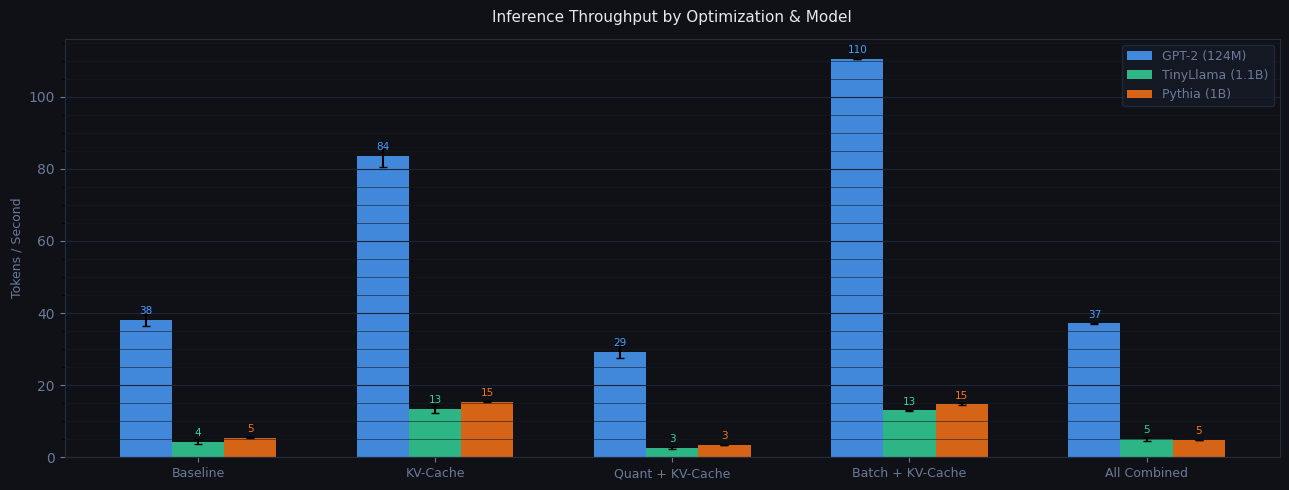

In [5]:
model_labels = list(all_model_results.keys())
n_models = len(model_labels)
n_configs = len(CONFIGS)

x = np.arange(n_configs)
width = 0.22
colors = ["#4a9eff", "#34d399", "#f97316"]

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

for i, (model_label, color) in enumerate(zip(model_labels, colors)):
    res = all_model_results[model_label]
    means = [res[c]["overall_tok_per_sec_mean"] for c in CONFIGS]
    stds  = [res[c]["overall_tok_per_sec_std"]  for c in CONFIGS]
    offset = (i - n_models / 2 + 0.5) * width
    bars = ax.bar(x + offset, means, width, yerr=stds, capsize=3,
                  label=model_label, color=color, alpha=0.85, edgecolor="none")
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{mean:.0f}", ha="center", va="bottom", fontsize=7.5, color=color)

ax.set_xticks(x)
ax.set_xticklabels([CONFIG_LABELS[c] for c in CONFIGS], color="#6b7a99", fontsize=9)
ax.set_ylabel("Tokens / Second", color="#6b7a99", fontsize=9)
ax.set_title("Inference Throughput by Optimization & Model", color="#e4e8f0", fontsize=11, pad=12)
ax.tick_params(colors="#6b7a99")
ax.spines[:].set_color("#252d3d")
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(axis="y", color="#1e2435", linewidth=0.8)
ax.grid(axis="y", which="minor", color="#161b27", linewidth=0.4)
ax.legend(labelcolor="#6b7a99", facecolor="#161b27", edgecolor="#252d3d", fontsize=9)
ax.set_ylim(bottom=0)

plt.tight_layout()
fig.savefig("../benchmark_results/final_all_models_bar.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

### 4b. Speedup relative to each model's own baseline

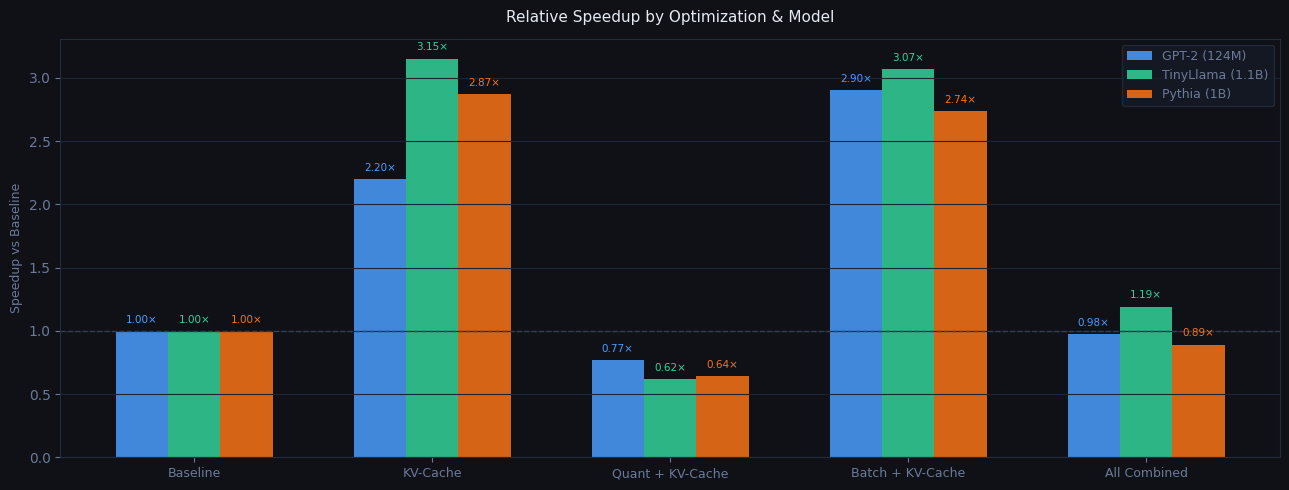

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

for i, (model_label, color) in enumerate(zip(model_labels, colors)):
    res = all_model_results[model_label]
    baseline_speed = res["baseline"]["overall_tok_per_sec_mean"]
    speedups = [res[c]["overall_tok_per_sec_mean"] / baseline_speed for c in CONFIGS]
    offset = (i - n_models / 2 + 0.5) * width
    bars = ax.bar(x + offset, speedups, width, label=model_label,
                  color=color, alpha=0.85, edgecolor="none")
    for bar, sp in zip(bars, speedups):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{sp:.2f}×", ha="center", va="bottom", fontsize=7.5, color=color)

ax.axhline(1.0, color="#363e52", linewidth=1, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels([CONFIG_LABELS[c] for c in CONFIGS], color="#6b7a99", fontsize=9)
ax.set_ylabel("Speedup vs Baseline", color="#6b7a99", fontsize=9)
ax.set_title("Relative Speedup by Optimization & Model", color="#e4e8f0", fontsize=11, pad=12)
ax.tick_params(colors="#6b7a99")
ax.spines[:].set_color("#252d3d")
ax.grid(axis="y", color="#1e2435", linewidth=0.8)
ax.legend(labelcolor="#6b7a99", facecolor="#161b27", edgecolor="#252d3d", fontsize=9)
ax.set_ylim(bottom=0)

plt.tight_layout()
fig.savefig("../benchmark_results/final_speedup_relative.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

### 4c. Memory footprint — FP32 vs INT8 for all models

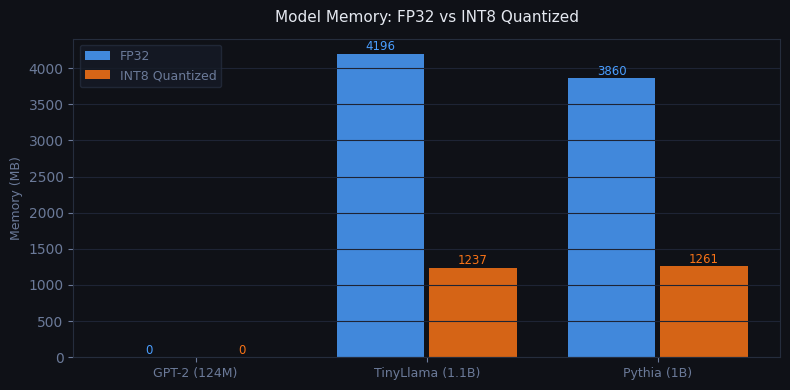

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

x_mem = np.arange(len(model_labels))
fp32_sizes = [all_model_results[m]["_meta"]["fp32_mb"] for m in model_labels]
int8_sizes = [all_model_results[m]["_meta"]["int8_mb"] for m in model_labels]

b1 = ax.bar(x_mem - 0.2, fp32_sizes, 0.38, label="FP32", color="#4a9eff", alpha=0.85, edgecolor="none")
b2 = ax.bar(x_mem + 0.2, int8_sizes, 0.38, label="INT8 Quantized", color="#f97316", alpha=0.85, edgecolor="none")

for bar, val in zip(b1, fp32_sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f"{val:.0f}", ha="center", va="bottom", fontsize=8.5, color="#4a9eff")
for bar, val in zip(b2, int8_sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f"{val:.0f}", ha="center", va="bottom", fontsize=8.5, color="#f97316")

ax.set_xticks(x_mem)
ax.set_xticklabels(model_labels, color="#6b7a99", fontsize=9)
ax.set_ylabel("Memory (MB)", color="#6b7a99", fontsize=9)
ax.set_title("Model Memory: FP32 vs INT8 Quantized", color="#e4e8f0", fontsize=11, pad=12)
ax.tick_params(colors="#6b7a99")
ax.spines[:].set_color("#252d3d")
ax.grid(axis="y", color="#1e2435", linewidth=0.8)
ax.legend(labelcolor="#6b7a99", facecolor="#161b27", edgecolor="#252d3d", fontsize=9)
ax.set_ylim(bottom=0)

plt.tight_layout()
fig.savefig("../benchmark_results/final_memory_comparison.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

### 4d. Per-model breakdown (individual speedup curves)

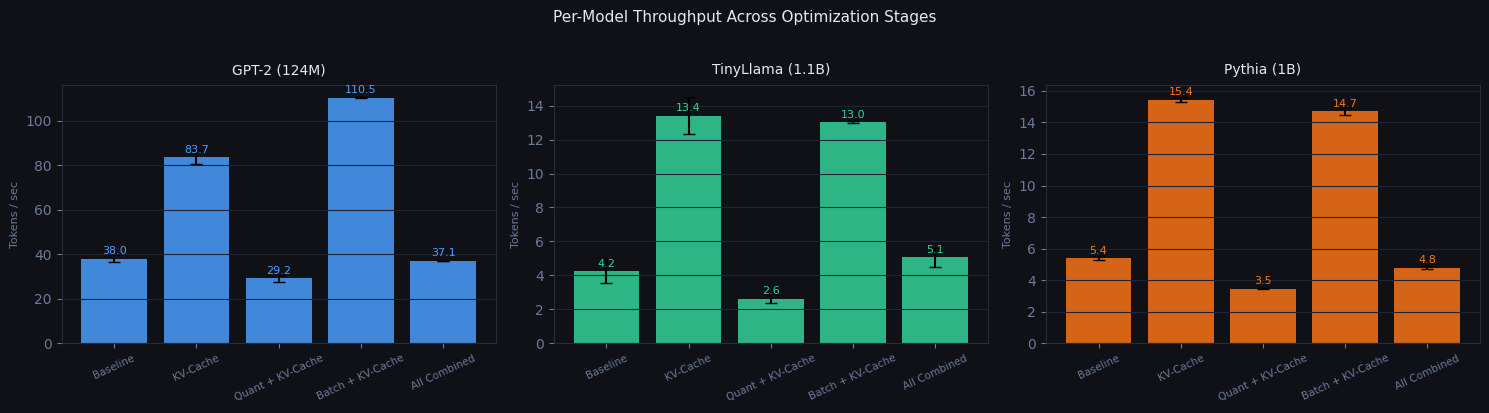

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.patch.set_facecolor("#0f1117")

for ax, (model_label, color) in zip(axes, zip(model_labels, colors)):
    res = all_model_results[model_label]
    means = [res[c]["overall_tok_per_sec_mean"] for c in CONFIGS]
    stds  = [res[c]["overall_tok_per_sec_std"]  for c in CONFIGS]
    cfg_names = [CONFIG_LABELS[c] for c in CONFIGS]

    ax.set_facecolor("#0f1117")
    bars = ax.bar(cfg_names, means, yerr=stds, capsize=4,
                  color=color, alpha=0.85, edgecolor="none")
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(means)*0.01,
                f"{mean:.1f}", ha="center", va="bottom", fontsize=8, color=color)

    ax.set_title(model_label, color="#e4e8f0", fontsize=10, pad=8)
    ax.set_ylabel("Tokens / sec", color="#6b7a99", fontsize=8)
    ax.tick_params(axis="x", rotation=25, labelsize=7.5, colors="#6b7a99")
    ax.tick_params(axis="y", colors="#6b7a99")
    ax.spines[:].set_color("#252d3d")
    ax.grid(axis="y", color="#1e2435", linewidth=0.8)
    ax.set_ylim(bottom=0)

fig.suptitle("Per-Model Throughput Across Optimization Stages",
             color="#e4e8f0", fontsize=11, y=1.02)
plt.tight_layout()
fig.savefig("../benchmark_results/final_per_model.png", dpi=150,
            facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()

### 4e. Profiling breakdown (cProfile — where time is spent in baseline)

In [9]:
# Show line_profiler output for GPT-2 baseline as profiling evidence
from src.profiling import line_profile_function

model_gpt2, tokenizer_gpt2 = load_model_and_tokenizer("gpt2")
lp = line_profile_function(generate_manual, model_gpt2, tokenizer_gpt2,
                            "The meaning of life is", max_new_tokens=30)
print(lp["report"])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

/Users/shriranjanpatil/Data/NYU/Spring_26/Adv_Python_DS/Final_Project/.venv/lib/python3.11/site-packages/line_profiler/line_profiler.py:529: UserWarning: Adding a function with a `.__wrapped__` attribute. You may want to profile the wrapped function by adding `generate_manual.__wrapped__` instead.
  self.add_function(impl)


Timer unit: 1e-09 s

Total time: 1.35022 s
File: /Users/shriranjanpatil/Data/NYU/Spring_26/Adv_Python_DS/Final_Project/notebooks/../src/inference.py
Function: generate_manual at line 60

Line #      Hits         Time  Per Hit   % Time  Line Contents
    60                                           @torch.no_grad()
    61                                           def generate_manual(
    62                                               model: PreTrainedModel,
    63                                               tokenizer: PreTrainedTokenizer,
    64                                               prompt: str,
    65                                               max_new_tokens: int = MAX_NEW_TOKENS,
    66                                               temperature: float = TEMPERATURE,
    67                                               top_k: int = TOP_K,
    68                                           ) -> dict:
    69                                               """
    70            

---
## 5. Quality Sanity Check — All Models

In [10]:
from src.config import format_prompt

check_prompts = ["What is Python?", "The capital of France is", "Water freezes at"]

for model_label, model_id in AVAILABLE_MODELS.items():
    print(f"\n{'─'*60}")
    print(f"  {model_label}")
    print(f"{'─'*60}")
    m, tok = load_model_and_tokenizer(model_id)
    for prompt in check_prompts:
        fp = format_prompt(prompt, model_id)
        result = generate_with_kv_cache(m, tok, fp, max_new_tokens=60)
        text = result["text"]
        # Strip template for display
        if "<|assistant|>" in text:
            reply = text.split("<|assistant|>")[-1].strip()
        elif text.startswith(fp):
            reply = text[len(fp):].strip()
        else:
            reply = text[len(prompt):].strip()
        print(f"  Q: {prompt}")
        print(f"  A: {reply[:200]}")
        print()
    del m


────────────────────────────────────────────────────────────
  GPT-2 (124M)
────────────────────────────────────────────────────────────


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Q: What is Python?
  A: Python is a programming language that has been around for several years. It allows one to easily integrate with a large number of environments. I hope this will help you understand programming better 

  Q: The capital of France is
  A: the G7.

The U.S., Sweden, Canada, India, Germany, India

The U.K.'s exit from the EU in 2015 meant the UK would become an EU member by 2020 and will face political and technical hurdles in coming to 

  Q: Water freezes at
  A: 70°F with a daily 1% freezing temperature, which is around 3% below the boiling point. This means a boil at 70°F means that a little extra water could have made the meat, cooked in the microwave and s


────────────────────────────────────────────────────────────
  TinyLlama (1.1B)
────────────────────────────────────────────────────────────


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Q: What is Python?
  A: Python is a programming language that focuses on readability, efficiency, and simplicity. It's a dynamic, interpreted scripting language with a user-friendly syntax, which makes it highly versatile an

  Q: The capital of France is
  A: The capital of France is Paris.

  Q: Water freezes at
  A: The statement "Water freezes at" is used to inform the observer that water molecules tend to align into straight lines when exposed to a lower temperature. A liquid will become solid when its temperat


────────────────────────────────────────────────────────────
  Pythia (1B)
────────────────────────────────────────────────────────────


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  Q: What is Python?
  A: The Python language has a lot of features and a lot of people use it. It has
many very useful features. But there are a lot of problems that are being
faced day after day. This is why for someone new 

  Q: The capital of France is
  A: a great place to meet your girlfriend as well as get you in the mood. Located in the very heart of Paris, our location in the heart of the Marais, makes your evenings here a delight. You will find it 

  Q: Water freezes at
  A: −23 °C but a decrease in temperature produces an increase in water contents in the aqueous solutions and a reduction of water contents in ice \[[@CR32], [@CR33]\]. A decrease in aqueous solution moist



---
## 6. Final Summary

### Benchmark Results (CPU, 50 tokens, 5 prompts, 5 runs)

| Model | Baseline | KV-Cache | Quant+KV | Batch+KV | All Combined |
|---|---|---|---|---|---|
| GPT-2 (124M) | 38 tok/s | 84 tok/s (2.2×) | 29 tok/s (0.77×) | 110 tok/s (2.9×) | 37 tok/s (0.98×) |
| TinyLlama (1.1B) | 4.3 tok/s | 13.4 tok/s (3.1×) | 2.6 tok/s (0.62×) | 13.0 tok/s (3.1×) | 5.1 tok/s (1.2×) |
| Pythia (1B) | 5.4 tok/s | 15.4 tok/s (2.9×) | 3.5 tok/s (0.64×) | 14.7 tok/s (2.7×) | 4.8 tok/s (0.89×) |

### Key Findings

| Finding | Detail |
|---|---|
| **Best single technique** | KV-Cache — 2.2–3.1× speedup across all models, zero quality tradeoff |
| **Best throughput (GPT-2)** | Batching (bs=2) + KV-Cache — 2.9× speedup, most effective on small models |
| **Batching vs KV-Cache (1B models)** | Roughly equal — larger models have smaller batching gains due to memory pressure |
| **Quantization tradeoff** | INT8 saves 43–70% memory but *slows* inference on CPU (dequantize overhead > bandwidth savings) |
| **All Combined** | Does not compound gains — quantization overhead cancels batching benefit on CPU |
| **Larger models** | ~9× slower than GPT-2 in absolute terms; KV-Cache gives slightly higher relative speedup |

### Course Tools Applied

| Tool | Application |
|---|---|
| `cProfile` | Function-level profiling — identified model forward pass as bottleneck |
| `line_profiler` | Line-level — confirmed 96.7% of time in `model(generated_ids)` call |
| `tracemalloc` | Memory allocation tracking during generation |
| **NumPy** | Pre-allocated KV-cache buffers, INT8 quantization scaling |
| **Numba** `@njit` | JIT-compiled INT8 matrix multiplication kernel |
| **asyncio** | Non-blocking coordination for async batching |
| **matplotlib** | All benchmark visualizations |